In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración global
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
})


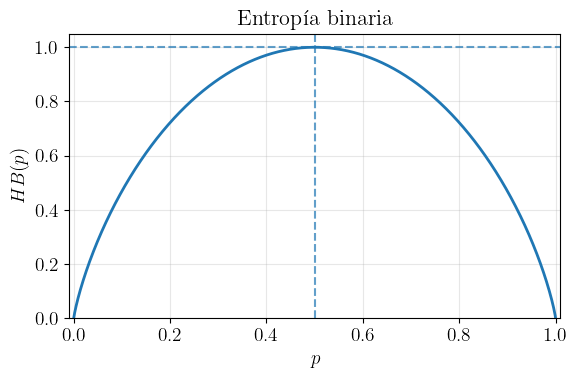

In [ ]:
# Dominio
p = np.linspace(1e-6, 1 - 1e-6, 1000)
H = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# Figura
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(p, H, lw=2)
ax.axvline(0.5, ls="--", alpha=0.7)
ax.axhline(1,ls="--", alpha=0.7)

ax.set_xlabel(r"$p$")
ax.set_ylabel(r"$HB(p)$")
ax.set_title("Entropía binaria")
ax.set_xlim(-0.01,1.01)
ax.set_ylim(0,1.05)

ax.grid(alpha=0.3)
fig.tight_layout()

plt.show()

<>:48: SyntaxWarning: invalid escape sequence '\c'
<>:59: SyntaxWarning: invalid escape sequence '\S'
<>:48: SyntaxWarning: invalid escape sequence '\c'
<>:59: SyntaxWarning: invalid escape sequence '\S'
C:\Users\alban\AppData\Local\Temp\ipykernel_26404\3377029850.py:48: SyntaxWarning: invalid escape sequence '\c'
  draw_box(ax, 2.4, 2.5, 1.2, 1.0, "Linear Layer\n$W \cdot x + b$", "#ECFDF5", "#10B981")
C:\Users\alban\AppData\Local\Temp\ipykernel_26404\3377029850.py:59: SyntaxWarning: invalid escape sequence '\S'
  draw_box(ax, 8.6, 2.5, 1.0, 1.0, "Cross\nEntropy\n$-\Sigma y_i \log(p_i)$", "#FEF2F2", "#EF4444")


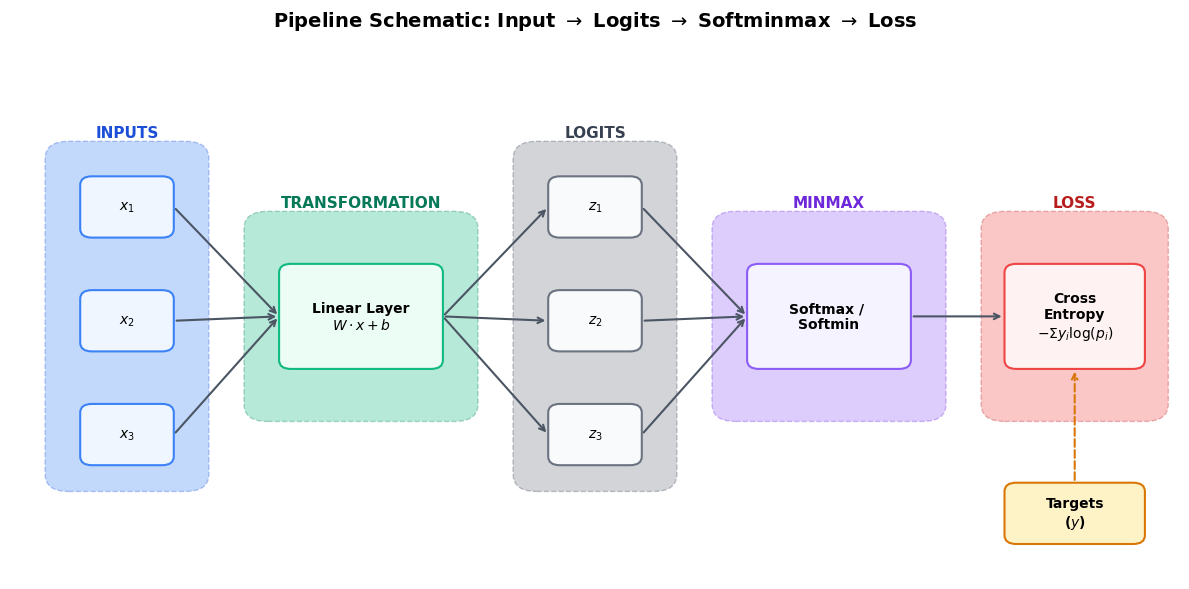

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Initialize the plot canvas
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')  # Hide the main graph axes

# Helper function to draw a stylized box
def draw_box(ax, x, y, width, height, text, bg_color, border_color):
    rect = patches.FancyBboxPatch(
        (x, y), width, height, boxstyle="round,pad=0.1",
        linewidth=1.5, edgecolor=border_color, facecolor=bg_color
    )
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', 
            fontsize=10, fontweight='bold', color='black', wrap=True)

# Helper function to draw a container/cluster background
def draw_cluster(ax, x, y, width, height, title, bg_color, border_color):
    rect = patches.FancyBboxPatch(
        (x, y), width, height, boxstyle="round,pad=0.2",
        linewidth=1, linestyle='--', edgecolor=border_color, facecolor=bg_color, alpha=0.3
    )
    ax.add_patch(rect)
    ax.text(x + width/2, y + height + 0.3, title, ha='center', va='center', 
            fontsize=11, fontweight='bold', color=border_color)

# ------------------------------------------------------------------
# DRAW GROUPS / BACKGROUNDS
# ------------------------------------------------------------------
draw_cluster(ax, 0.5, 1.2, 1.0, 3.6, "INPUTS", "#3B82F6", "#1D4ED8")
draw_cluster(ax, 2.2, 2.0, 1.6, 2.0, "TRANSFORMATION", "#10B981", "#047857")
draw_cluster(ax, 4.5, 1.2, 1.0, 3.6, "LOGITS", "#6B7280", "#374151")
draw_cluster(ax, 6.2, 2.0, 1.6, 2.0, "MINMAX", "#8B5CF6", "#6D28D9")
draw_cluster(ax, 8.5, 2.0, 1.2, 2.0, "LOSS", "#EF4444", "#B91C1C")

# ------------------------------------------------------------------
# DRAW INDIVIDUAL NODES
# ------------------------------------------------------------------
# Inputs
draw_box(ax, 0.7, 4.0, 0.6, 0.5, "$x_1$", "#EFF6FF", "#3B82F6")
draw_box(ax, 0.7, 2.7, 0.6, 0.5, "$x_2$", "#EFF6FF", "#3B82F6")
draw_box(ax, 0.7, 1.4, 0.6, 0.5, "$x_3$", "#EFF6FF", "#3B82F6")

# Hidden Layer Layer
draw_box(ax, 2.4, 2.5, 1.2, 1.0, "Linear Layer\n$W \cdot x + b$", "#ECFDF5", "#10B981")

# Logits
draw_box(ax, 4.7, 4.0, 0.6, 0.5, "$z_1$", "#F9FAFB", "#6B7280")
draw_box(ax, 4.7, 2.7, 0.6, 0.5, "$z_2$", "#F9FAFB", "#6B7280")
draw_box(ax, 4.7, 1.4, 0.6, 0.5, "$z_3$", "#F9FAFB", "#6B7280")

# Minmax Activation
draw_box(ax, 6.4, 2.5, 1.2, 1.0, "Softmax / \nSoftmin", "#F5F3FF", "#8B5CF6")

# Cross Entropy Loss
draw_box(ax, 8.6, 2.5, 1.0, 1.0, "Cross\nEntropy\n$-\Sigma y_i \log(p_i)$", "#FEF2F2", "#EF4444")

# Ground Truth Input
draw_box(ax, 8.6, 0.5, 1.0, 0.5, "Targets\n($y$)", "#FEF3C7", "#D97706")

# ------------------------------------------------------------------
# DRAW ARROWS (CONNECTIONS)
# ------------------------------------------------------------------
arrow_style = dict(arrowstyle="->", lw=1.5, color="#4B5563")

# Inputs to Hidden Layer
ax.annotate("", xy=(2.3, 3.0), xytext=(1.4, 4.25), arrowprops=arrow_style)
ax.annotate("", xy=(2.3, 3.0), xytext=(1.4, 2.95), arrowprops=arrow_style)
ax.annotate("", xy=(2.3, 3.0), xytext=(1.4, 1.65), arrowprops=arrow_style)

# Hidden Layer to Logits
ax.annotate("", xy=(4.6, 4.25), xytext=(3.7, 3.0), arrowprops=arrow_style)
ax.annotate("", xy=(4.6, 2.95), xytext=(3.7, 3.0), arrowprops=arrow_style)
ax.annotate("", xy=(4.6, 1.65), xytext=(3.7, 3.0), arrowprops=arrow_style)

# Logits to Minmax
ax.annotate("", xy=(6.3, 3.0), xytext=(5.4, 4.25), arrowprops=arrow_style)
ax.annotate("", xy=(6.3, 3.0), xytext=(5.4, 2.95), arrowprops=arrow_style)
ax.annotate("", xy=(6.3, 3.0), xytext=(5.4, 1.65), arrowprops=arrow_style)

# Minmax to Loss
ax.annotate("", xy=(8.5, 3.0), xytext=(7.7, 3.0), arrowprops=arrow_style)

# Ground Truth Target to Loss
ax.annotate("", xy=(9.1, 2.4), xytext=(9.1, 1.1), 
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#D97706", linestyle="--"))

# Add Title
plt.title("Pipeline Schematic: Input $\\rightarrow$ Logits $\\rightarrow$ Softminmax $\\rightarrow$ Loss", 
          fontsize=14, fontweight='bold', pad=20)

# Save image file
plt.tight_layout()
plt.savefig('pipeline_schematic.png', dpi=300, bbox_inches='tight')
plt.show()